### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 11/11 [00:13<00:00,  1.27s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834589,2026-03-12 18:59:35,69788.203125,69795.796875,69787.000000,69792.000000,0.652,0.272,0.016,0.256,-0.882353,...,0.003,0.020,0.857,0.667,0.303,0.580,0.007,0.342,0.004,0.002
834590,2026-03-12 18:59:40,69763.000000,69788.101562,69756.500000,69771.796875,6.382,0.197,0.000,0.197,-1.000000,...,0.002,0.094,0.002,0.080,0.007,0.020,0.057,0.011,0.010,0.002
834591,2026-03-12 18:59:45,69771.500000,69774.000000,69769.898438,69770.898438,0.150,0.106,0.103,0.003,0.943396,...,0.002,0.359,0.857,1.125,0.676,0.174,0.002,0.002,0.020,0.021
834592,2026-03-12 18:59:50,69788.000000,69788.000000,69774.101562,69776.898438,2.978,1.046,1.046,0.000,1.000000,...,0.575,0.911,0.157,0.010,0.020,0.002,0.857,1.125,0.629,0.174


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 834593/834593 [00:07<00:00, 118977.55it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.140969,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.133872,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.133872,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.130372,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.137529,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834589,8.320312,1.268594,13.428569,11.853021,7.871251e-07,8.320301,0.434000,-1.080155,-0.389859,-22.174977,...,0.447639,0.401963,-2.028360,-0.524681,-0.528915,69787.000000,69795.796875,69792.000000,-0.000282,0.000453
834590,8.170312,0.062648,14.164283,13.168765,1.939320e-07,8.170301,0.682000,2.667220,1.187615,37.406190,...,0.454575,2.692229,3.834174,0.881017,0.904284,69756.500000,69788.101562,69771.796875,0.000002,0.000059
834591,8.366927,0.340508,13.828859,12.894992,4.540594e-07,8.366915,0.919000,0.003901,0.047107,0.099689,...,0.434539,1.544059,0.346539,0.398385,0.406398,69769.898438,69774.000000,69770.898438,0.000145,0.000199
834592,8.243750,0.228703,13.937949,13.084524,1.341103e-06,8.243738,0.684000,0.321300,0.144635,8.178075,...,0.446463,1.272283,0.954877,0.401358,0.405592,69774.101562,69788.000000,69776.898438,0.000216,0.000110


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00020
[100]	validation_0-rmse:0.00020
[150]	validation_0-rmse:0.00020
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[450]	validation_0-rmse:0.00019
[500]	validation_0-rmse:0.00019
[550]	validation_0-rmse:0.00019
[600]	validation_0-rmse:0.00019
[650]	validation_0-rmse:0.00019
[700]	validation_0-rmse:0.00019
[750]	validation_0-rmse:0.00019
[800]	validation_0-rmse:0.00019
[850]	validation_0-rmse:0.00019
[900]	validation_0-rmse:0.00019
[950]	validation_0-rmse:0.00019
[1000]	validation_0-rmse:0.00019
[1050]	validation_0-rmse:0.00019
[1100]	validation_0-rmse:0.00019
[1150]	validation_0-rmse:0.00019
[1200]	validation_0-rmse:0.00019
[1250]	validation_0-rmse:0.00019
[1300]	validation_0-rmse:0.00019
[1350]	validation_0-rmse:0.00019
[1400]	validation_0-rmse:0.00019
[1450]	validation_0-rmse:0.00019
[1500]	validat

MAE                      : 0.000121
RMSE                     : 0.000189
R²                       : 0.208738
MAE / mean|Δ|            : 0.859133
RMSE / RMSE_base         : 0.889499
mean|Δ| (target)         : 0.000141

------------------------------------------------------------
Directional Accuracy     : 0.622833
Target Pos Ratio         : 0.484150
Profit Factor            : 1.799710
Avg Gain (correct)       : -0.000006
Avg Loss (incorrect)     : 0.000006

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6205, 0.6252)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc   mean_return  n_samples
 (0.000121, 0.00126]    0.000227         0.907860 -7.463966e-06      16692
(6.86e-05, 0.000121]    0.000090         0.762567 -4.591219e-06      16691
(4.71e-05, 6.86e-05]    0.000057         0.691091 -9.162659e-08      166

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


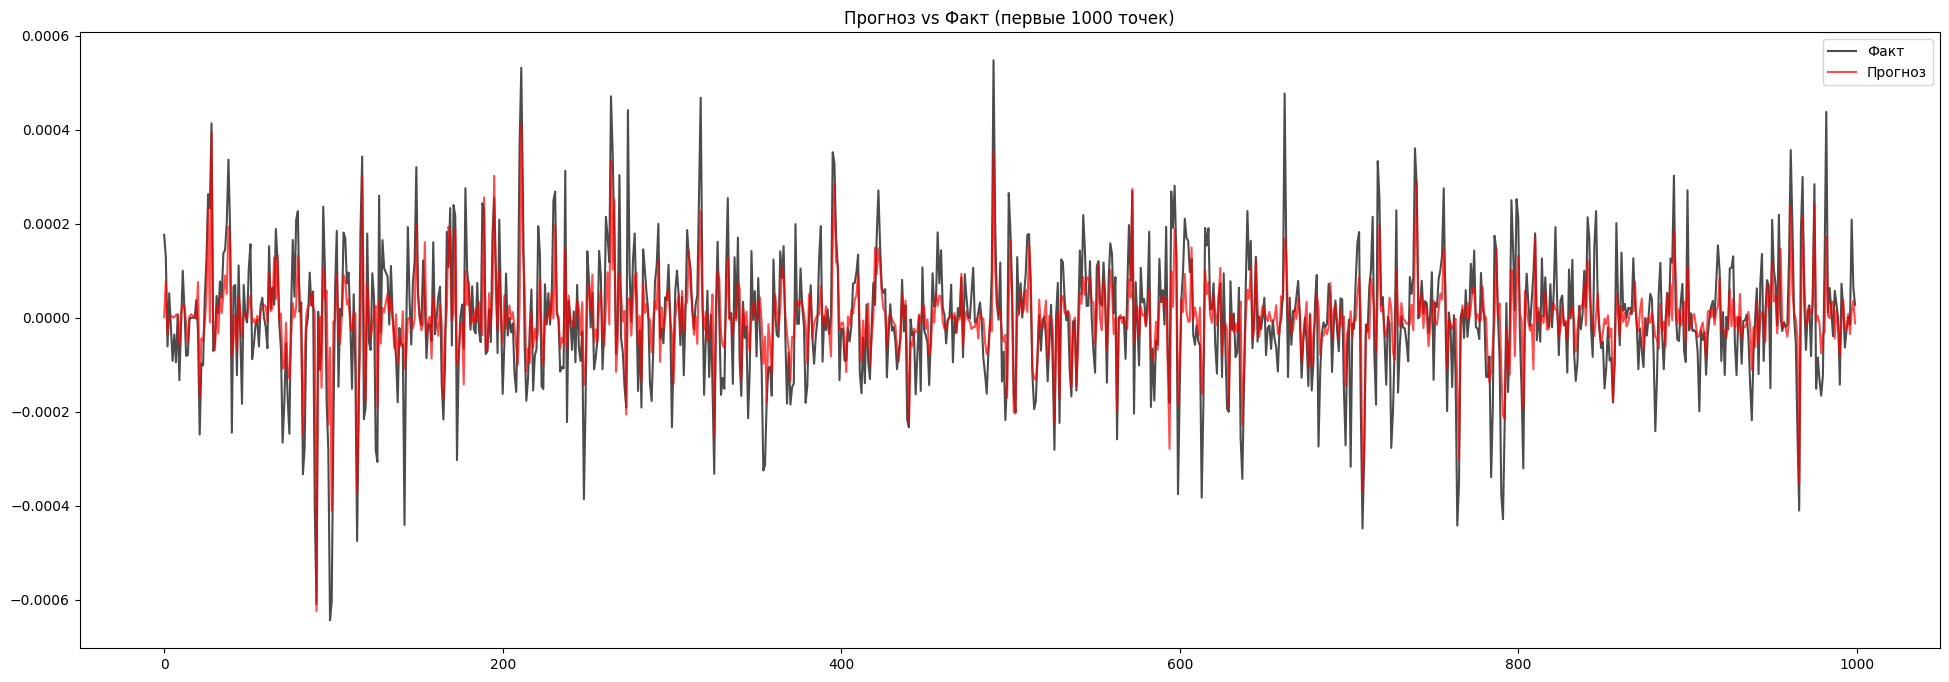

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00022
[50]	validation_0-rmse:0.00019
[100]	validation_0-rmse:0.00018
[150]	validation_0-rmse:0.00017
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00017
[300]	validation_0-rmse:0.00017
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[450]	validation_0-rmse:0.00017
[500]	validation_0-rmse:0.00017
[550]	validation_0-rmse:0.00017
[600]	validation_0-rmse:0.00017
[650]	validation_0-rmse:0.00017
[700]	validation_0-rmse:0.00017
[750]	validation_0-rmse:0.00017
[800]	validation_0-rmse:0.00017
[850]	validation_0-rmse:0.00017
[900]	validation_0-rmse:0.00017
[922]	validation_0-rmse:0.00017
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000114
RMSE                     : 0.000169
R²                       : 0.400536
MAE / mean|Δ|            : 0.528832
RMSE / RMSE_base         : 0.552262
mean|Δ| (target)         : 0.000215

------------------------------------------------------------
Directional Accuracy     : 0.932336
Target Pos Ratio         : 0.932336
Profit Factor            : 35863023216.636818
Avg Gain (correct)       : 0.000230
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9311, 0.9336)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
  (0.000396, 0.0023]    0.000535         0.999940     0.000529      16692
(0.000299, 0.000396]    0.000341         0.999161     0.000338      16691
(0.000246, 0.000299]    0.000272         0.996519     0.000272    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


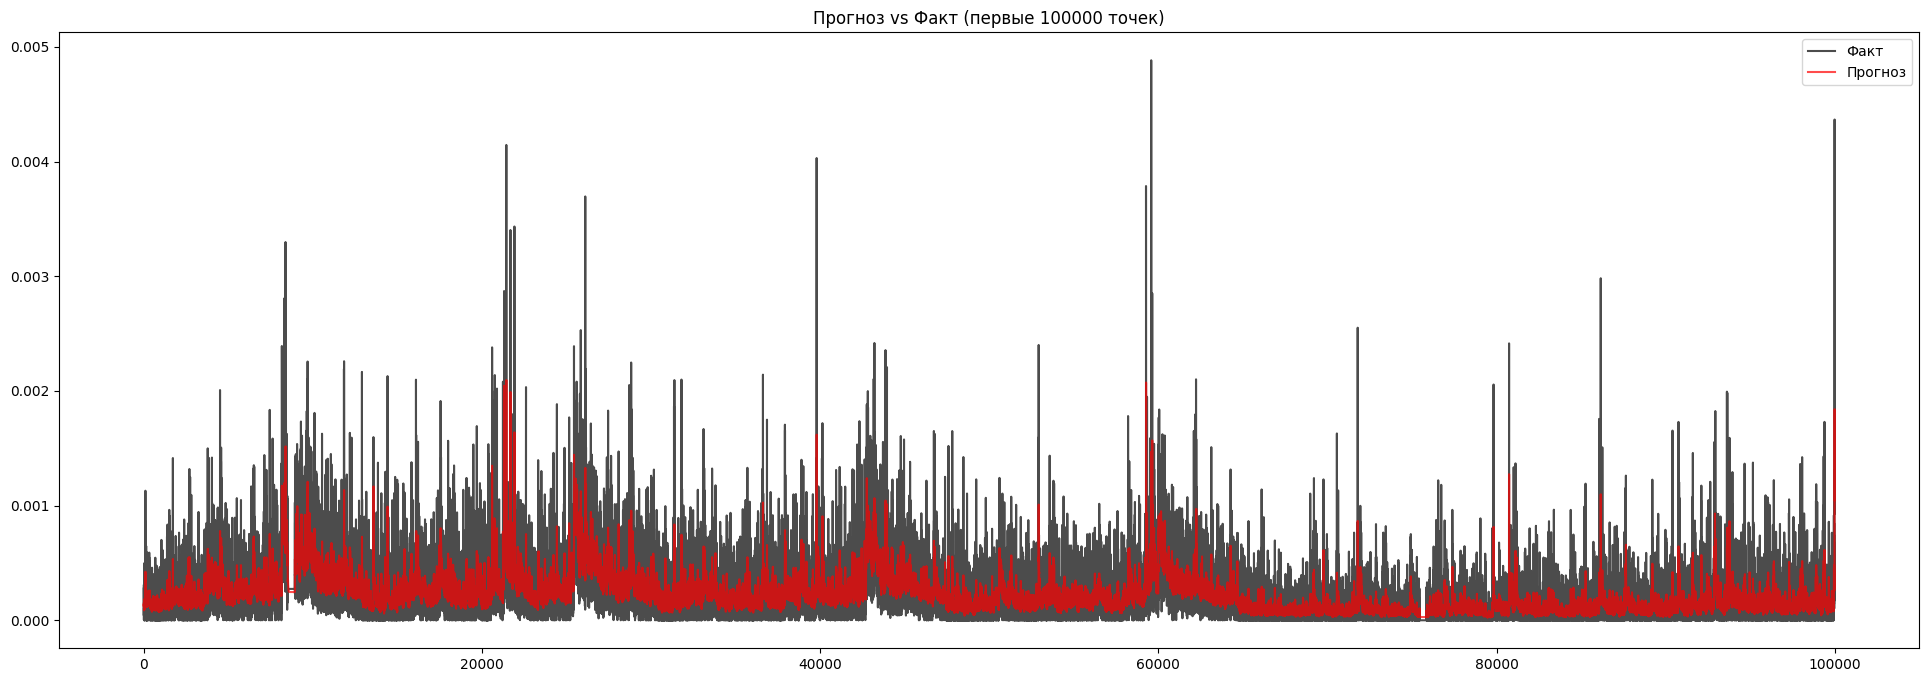

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)